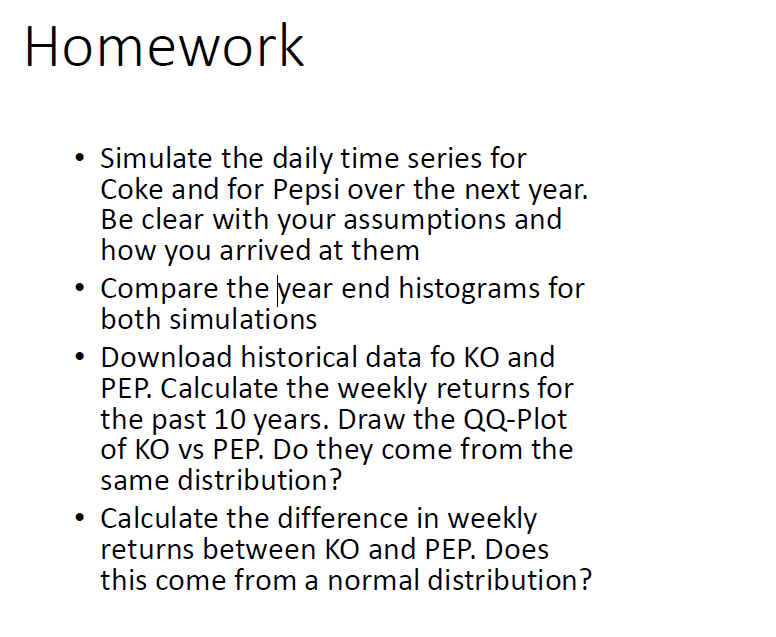

Simulate the stock price:
1. get mu_1y, implied_vol_1y
2. r = mu* delta_t + implied_vol * epsilon * sqrt(delta_t), epsilon~N(0,1), delta_t = 1/252 (trading day)
3. s_t = s_0*(1+r1)(1+r2)*...*(1+rt)
############################################################
<br> How to obtain the implied volatility?
Get implied volatility. At the money (K = St), one year later expiration date.
##### Need to write to interpolate the expiration to one year later, right now just use the fixed and date close to one year expiration.

In [60]:
import pandas as pd
import yfinance as yf
import numpy as np
from math import prod
from scipy.stats import norm
import random
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.diagnostic import normal_ad
from datetime import date
from dateutil.relativedelta import relativedelta

In [2]:
n_year = 1
n_month = 12
n_day = 252

### 1. Pull one year daily price data
end = pd.Timestamp.today().normalize()
start = end - pd.DateOffset(years=1)
tickers = ["KO", "PEP"]

raw = yf.download(tickers, start=start, end=end, auto_adjust=False,progress=False)
prices = raw["Adj Close"].copy()
KO_current_price = prices['KO'][-1] ### Current price of KO
pep_current_price = prices['PEP'][-1] ### Current price of PEP

C:\Users\w28sh\AppData\Local\Temp\ipykernel_34912\3032825653.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  KO_current_price = prices['KO'][-1] ### Current price of KO
C:\Users\w28sh\AppData\Local\Temp\ipykernel_34912\3032825653.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pep_current_price = prices['PEP'][-1] ### Current price of PEP


In [3]:
### 2. Calculate Return
daily_ret = prices.pct_change().dropna()
monthly_ret = prices.resample("M").last().pct_change().dropna()
one_year_total_return = (prices.iloc[-1] / prices.iloc[0] - 1).rename("1Y_total_return")
ko_annu_return = (prod(daily_ret['KO']+1))**(n_day/len(daily_ret['KO']))-1
pep_annu_return = (prod(daily_ret['PEP']+1))**(n_day/len(daily_ret['PEP']))-1

C:\Users\w28sh\AppData\Local\Temp\ipykernel_34912\3999429050.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ret = prices.resample("M").last().pct_change().dropna()


In [79]:
###3. Get implied volatility. 
stock_nm = 'KO'
ticker = yf.Ticker(stock_nm)
spot = ticker.history(period="1d")["Close"].iloc[-1]
divs = ticker.dividends
expiries = ticker.options
first_expiration_days = '2026-09-18'
calls_df  = ticker.option_chain(first_expiration_days).calls
put_df  = ticker.option_chain(first_expiration_days).puts
strike_price_lst = calls_df['strike'].unique().tolist()
at_the_money = strike_price_lst[np.abs(strike_price_lst - spot).argmin()]
call_implied_volatility = calls_df[calls_df['strike'] == at_the_money]
put_implied_volatility = put_df[put_df['strike'] == at_the_money]

if call_implied_volatility.shape[0]>0 and \
   put_implied_volatility.shape[0]>0 and \
   call_implied_volatility['impliedVolatility'].values[0]!= 0 and \
   put_implied_volatility['impliedVolatility'].values[0]!= 0:

    ko_implied_vol = (call_implied_volatility['impliedVolatility'].values[0]+ put_implied_volatility['impliedVolatility'].values[0])/2
    print(ko_implied_vol)

0.19266554412841796


In [80]:
stock_nm = 'PEP'
ticker = yf.Ticker(stock_nm)
spot = ticker.history(period="1d")["Close"].iloc[-1]
divs = ticker.dividends
expiries = ticker.options
first_expiration_days = '2026-09-18'
calls_df  = ticker.option_chain(first_expiration_days).calls
put_df  = ticker.option_chain(first_expiration_days).puts
strike_price_lst = calls_df['strike'].unique().tolist()
at_the_money = strike_price_lst[np.abs(strike_price_lst - spot).argmin()]
call_implied_volatility = calls_df[calls_df['strike'] == at_the_money]
put_implied_volatility = put_df[put_df['strike'] == at_the_money]

if call_implied_volatility.shape[0]>0 and \
   put_implied_volatility.shape[0]>0 and \
   call_implied_volatility['impliedVolatility'].values[0]!= 0 and \
   put_implied_volatility['impliedVolatility'].values[0]!= 0:

    pep_implied_vol = (call_implied_volatility['impliedVolatility'].values[0]+ put_implied_volatility['impliedVolatility'].values[0])/2
    print(pep_implied_vol)

0.24349206222534178


### Q1: Simulate the daily time series for Coke and for Pepsi over the next year.
### Q2: Compare the year end histogram.
<br> consumption: volatility and mean of the return remains constant through the year
<br> Histogram of the Pepsi and the coke year end price is similar shape.

In [82]:
delta_t = 1/n_day
one_trail = np.random.normal(0, 1, n_day)
n_trail = 10000

In [83]:
class simulate_steps_2way:
    def __init__(self, mu, sigma, n_days, n_trail, current_price, return_mu,implied_vol, upper_bound = None, lower_bound = None):
        self.mu =mu
        self.sigma = sigma
        self.n_days = n_days
        self.n_trail = n_trail
        self.current_price = current_price
        self.return_mu = return_mu
        self.implied_vol = implied_vol
        self.sim_return_result = self.sim_return()
        self.last_step = self.sim_return_result[self.n_days-1]

    def sim_return(self):
        agg_trail_result = []
        for i in range(self.n_trail):
            one_trail = np.random.normal(self.mu , self.sigma, self.n_days)
            delta_t = 1/self.n_days
            r = self.return_mu* delta_t + self.implied_vol * one_trail* np.sqrt(delta_t)
            agg_trail_result.append(r)
            
        agg_trail_result = pd.DataFrame(agg_trail_result).reset_index(drop = True)
        agg_trail_result = agg_trail_result+1
        sim_return_prod = agg_trail_result.cumprod(axis=1) 
        sim_return_prod = sim_return_prod * self.current_price
        return sim_return_prod

    def generate_step_plot(self):
        self.sim_return_result.T.plot(legend=False, title='Independent Trial of Random Walk')
        plt.xlabel('Time Step')
        plt.ylabel('Random Walk Value')
        plt.show()
    
    def generate_hist_plot(self):
        n_bins = int(1 + np.log2(self.n_trail))
        print(n_bins)
        
        plt.hist(self.last_step, bins=n_bins, color='skyblue', edgecolor='black', alpha=0.7)

        lower_CI = np.mean(self.last_step) - 1.96 * np.std(self.last_step)
        upper_CI = np.mean(self.last_step) + 1.96 * np.std(self.last_step)
        
        plt.axvline(x=lower_CI, color='red', linestyle='--', linewidth=2, label='Mean - 1.96·STD (95%CI)')
        plt.axvline(x=upper_CI, color='red', linestyle='--', linewidth=2, label='Mean + 1.96·STD (95%CI)')

        plt.title(f'Distribution of Stock Price.')
        plt.xlabel('Final value')
        plt.ylabel('Frequency')
        plt.show()

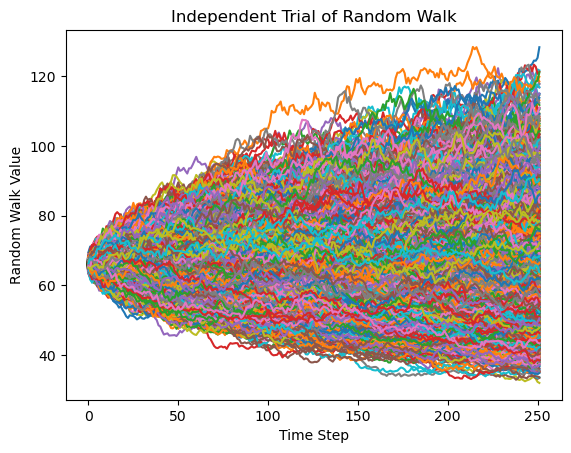

14


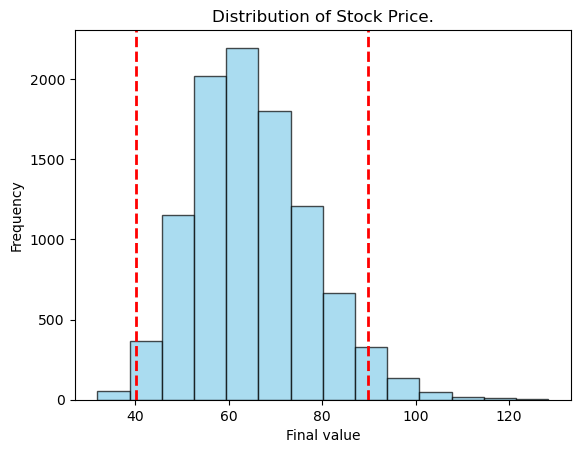

In [84]:
ko_price_simulation = simulate_steps_2way(0, 1,n_day, n_trail, KO_current_price,ko_annu_return, ko_implied_vol  )
ko_price_simulation.generate_step_plot()
ko_price_simulation.generate_hist_plot()

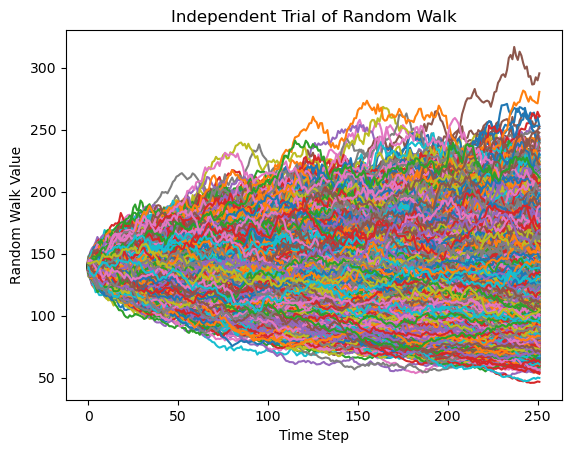

14


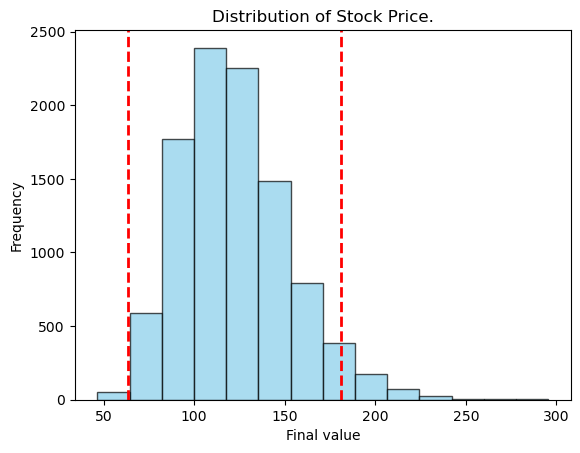

In [85]:
pep_price_simulation = simulate_steps_2way(0, 1,n_day, n_trail, pep_current_price,pep_annu_return, pep_implied_vol  )
pep_price_simulation.generate_step_plot()
pep_price_simulation.generate_hist_plot()

### Q3. Download historical data fo KO and PEP. Calculate the weekly returns for the past 10 years. Draw the QQ-Plot of KO vs PEP. 
Do they come from the same distribution?
<br> Answer: Yes, they has same distribution based on the statistical test.
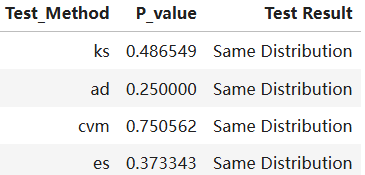

In [86]:
### 1. Pull 10 year daily price data
end = pd.Timestamp.today().normalize()
start = end - pd.DateOffset(years=10)
tickers = ["KO", "PEP"]

raw = yf.download(tickers, start=start, end=end, auto_adjust=False,progress=False)
prices = raw["Adj Close"].copy()

### 2. Weekly Return
wk_last = prices.resample("W-FRI").last()
wk_ret = wk_last.pct_change().dropna()
wk_ret['Year'] = [str(i).split('-')[0] for i in wk_ret.index]

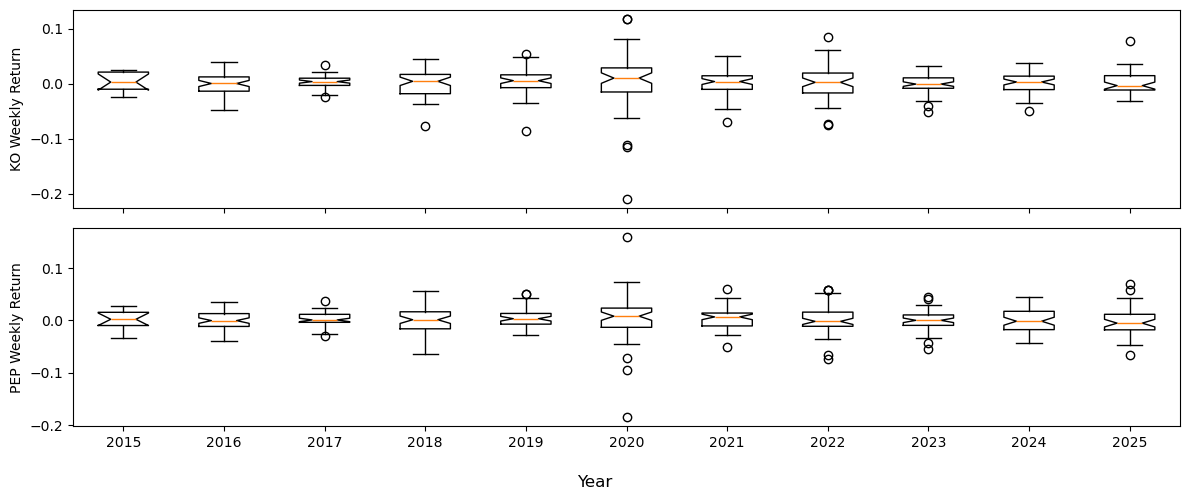

In [87]:
years = wk_ret['Year'].unique()
data_ko  = [wk_ret.loc[wk_ret["Year"] == y, "KO"].dropna().values  for y in years]
data_pep = [wk_ret.loc[wk_ret["Year"] == y, "PEP"].dropna().values for y in years]

fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

ax[0].boxplot(data_ko, notch=True, showfliers=True)
ax[0].set_ylabel("KO Weekly Return")

ax[1].boxplot(data_pep, notch=True, showfliers=True)
ax[1].set_ylabel("PEP Weekly Return")

ax[1].set_xticks(range(1, len(years) + 1))
ax[1].set_xticklabels(years, rotation=0)
fig.supxlabel("Year")
fig.tight_layout()
plt.show()

Text(0.5, 1.0, 'Distribution of KO Weekly Return.')

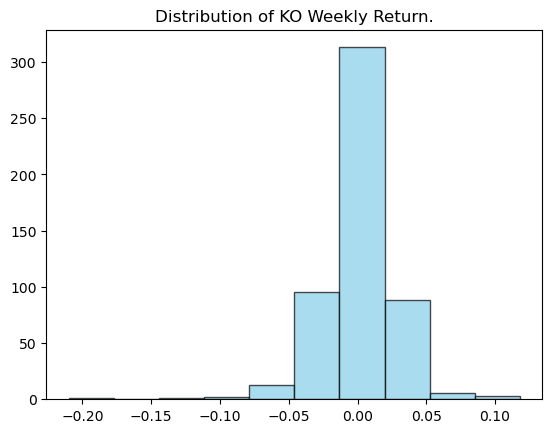

In [88]:
n_bins = int(1 + np.log2(wk_ret.shape[0]))
plt.hist(wk_ret['KO'], bins=n_bins, color='skyblue', edgecolor='black', alpha=0.7)
plt.title(f'Distribution of KO Weekly Return.')

Text(0.5, 1.0, 'Distribution of PEP Weekly Return.')

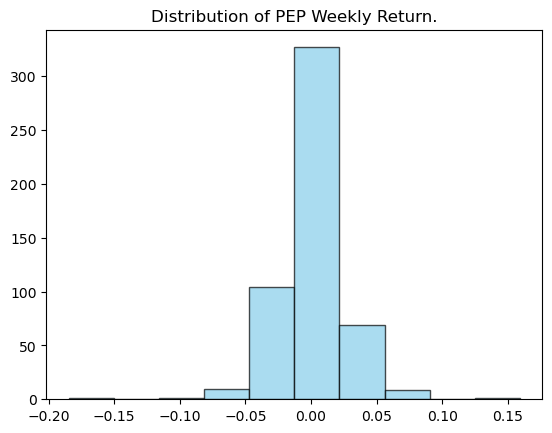

In [89]:
n_bins = int(1 + np.log2(wk_ret.shape[0]))
plt.hist(wk_ret['PEP'], bins=n_bins, color='skyblue', edgecolor='black', alpha=0.7)
plt.title(f'Distribution of PEP Weekly Return.')

In [90]:
def same_distribution_tests(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]

    results = {
        "ks":  stats.ks_2samp(x, y, alternative="two-sided", mode="auto"),
        "ad":  stats.anderson_ksamp([x, y]),            
        "cvm": stats.cramervonmises_2samp(x, y),       
        "es":  stats.epps_singleton_2samp(x, y),       
    }

    test_nm = ["ks", "ad", "cvm", "es"]
    p_value_lst = [results['ks'].pvalue, results['ad'].pvalue, 
                   results['cvm'].pvalue, results['es'].pvalue]

    results_output = pd.DataFrame({
    "Test_Method": test_nm,
    "P_value": p_value_lst
    })

    results_output['Test Result'] = results_output['P_value'].apply(lambda x: 'Same Distribution' if x> 0.05 else 'Not Same Distribution')
    return results_output

In [91]:
compare_distribution = same_distribution_tests(wk_ret['KO'], wk_ret['PEP'])
compare_distribution

C:\Users\w28sh\AppData\Local\Temp\ipykernel_34912\6524882.py:9: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  "ad":  stats.anderson_ksamp([x, y]),


,Test_Method,P_value,Test Result
0,ks,0.487795,Same Distribution
1,ad,0.250000,Same Distribution
2,cvm,0.749482,Same Distribution
3,es,0.360229,Same Distribution


### 4. Calculate the difference in weekly returns between KO and PEP. Does this come from a normal distribution?
Answer: No, both of the two distributions are not normal distribution based on the statistical test.

In [92]:
def same_distribution_tests(x):
    x = np.asarray(x, float)

    shapiro_stat, shapiro_p = stats.shapiro(x)
    k2_stat, k2_p           = stats.normaltest(x)        
    jb_stat, jb_p           = stats.jarque_bera(x)
    ad_stat, ad_p           = normal_ad(x)               

    results_output = pd.DataFrame({
        "Test_Method": ["Shapiro–Wilk", "D’Agostino K^2", "Jarque–Bera", "Anderson–Darling"],
        "Statistic":   [shapiro_stat,     k2_stat,          jb_stat,        ad_stat],
        "P_value":     [shapiro_p,        k2_p,             jb_p,           ad_p]
    })
    results_output['Test Result'] = results_output['P_value'].apply(lambda x: 'Not normal' if x<= 0.05 else 'Normal Distribution')
    return results_output

In [93]:
same_distribution_tests(wk_ret['KO'])

,Test_Method,Statistic,P_value,Test Result
0,Shapiro–Wilk,0.895040,2.021302e-18,Not normal
1,D’Agostino K^2,189.677812,6.486142e-42,Not normal
2,Jarque–Bera,2863.256015,0.000000e+00,Not normal
3,Anderson–Darling,7.408296,4.091568e-18,Not normal


In [94]:
same_distribution_tests(wk_ret['PEP'])

,Test_Method,Statistic,P_value,Test Result
0,Shapiro–Wilk,0.929977,6.658700e-15,Not normal
1,D’Agostino K^2,109.862003,1.392417e-24,Not normal
2,Jarque–Bera,1616.153696,0.000000e+00,Not normal
3,Anderson–Darling,4.114782,3.034809e-10,Not normal
